In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel(r"C:\Users\Yug\Downloads\data_.xlsx")
df

,Sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sno          6 non-null      int64  
 1   Temperature  6 non-null      int64  
 2   Pressure     6 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 276.0 bytes


Sno            0
Temperature    0
Pressure       0
dtype: int64

In [4]:
X = df.iloc[:, 1].values.reshape(-1, 1)
y = df.iloc[:, 2].values
X, y

(array([[  0],
        [ 20],
        [ 40],
        [ 60],
        [ 80],
        [100]]),
 array([2.0e-04, 1.2e-03, 6.0e-03, 3.0e-02, 9.0e-02, 2.7e-01]))

In [5]:
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

In [8]:
print("MODEL PERFORMANCE\n")

print("TRAIN DATA")
print("R2 :", r2_score(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

print("\nTEST DATA")
print("R2 :", r2_score(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

MODEL PERFORMANCE

TRAIN DATA
R2 : 1.0
MSE: 2.7505176023930154e-30
MAE: 1.3838756529604979e-15

TEST DATA
R2 : -3752.09121740309
MSE: 0.0009382728043507723
MAE: 0.02939115711536163


In [9]:
y_pred_all = model.predict(poly.transform(X))

print("OVERALL DATA")
print("R2 :", r2_score(y, y_pred_all))
print("MSE:", mean_squared_error(y, y_pred_all))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred_all)))
print("MAE:", mean_absolute_error(y, y_pred_all))

OVERALL DATA
R2 : 0.9662591037306135
MSE: 0.0003127576014502574
RMSE: 0.017684954098053447
MAE: 0.009797052371788134


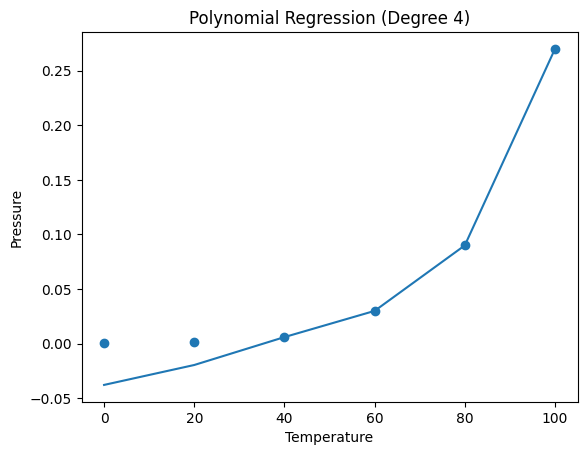

In [10]:
plt.scatter(X, y)
plt.plot(X, y_pred_all)
plt.xlabel("Temperature")
plt.ylabel("Pressure")
plt.title("Polynomial Regression (Degree 4)")
plt.show()